In [1]:
# =================================================================
# 05b_chronicle_eda
# Goal: Exploratory data analysis on the unified ML dataset.
#
# Requires: unified_ml_dataset_LIGHTWEIGHT.pkl (produced by 05a)
#
# Sections:
#   1. Dataset overview (shape, class balance, missing values)
#   2. Rainfall intensity distributions by class
#   3. Intensity-duration curves (flood vs no-flood)
#   4. Spatial and hydrological feature distributions
# =================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── CONFIGURATION ─────────────────────────────────────────────────
LIGHTWEIGHT_PATH   = r"D:\Development\RESEARCH\urban_flood_database\chronicle\unified_ml_dataset_LIGHTWEIGHT.pkl"
URBAN_THRESHOLD    = 20.0
THRESH_1H          = 7.0
THRESH_24H         = 1.0

INTENSITY_COLS = [
    '30_max_rainfall_intens',  '60_max_rainfall_intens',
    '120_max_rainfall_intens', '240_max_rainfall_intens',
    '360_max_rainfall_intens', '720_max_rainfall_intens',
    '1440_max_rainfall_intens',
]
DURATION_LABELS = ['30m', '60m', '120m', '240m', '360m', '720m', '1440m']

sns.set_theme(style='whitegrid')

# ── LOAD ──────────────────────────────────────────────────────────
print("Loading LIGHTWEIGHT dataset...")
df = pd.read_pickle(LIGHTWEIGHT_PATH)
print(f"Shape: {df.shape}")

Loading LIGHTWEIGHT dataset...
Shape: (852384, 23)


Total events:    852,384
Flood (1):       844,982  (99.1%)
No-flood (0):    7,402  (0.9%)

Missing values:
30_max_rainfall_intens      605
60_max_rainfall_intens      605
120_max_rainfall_intens     605
240_max_rainfall_intens     605
360_max_rainfall_intens     605
720_max_rainfall_intens     605
1440_max_rainfall_intens    605
dtype: int64


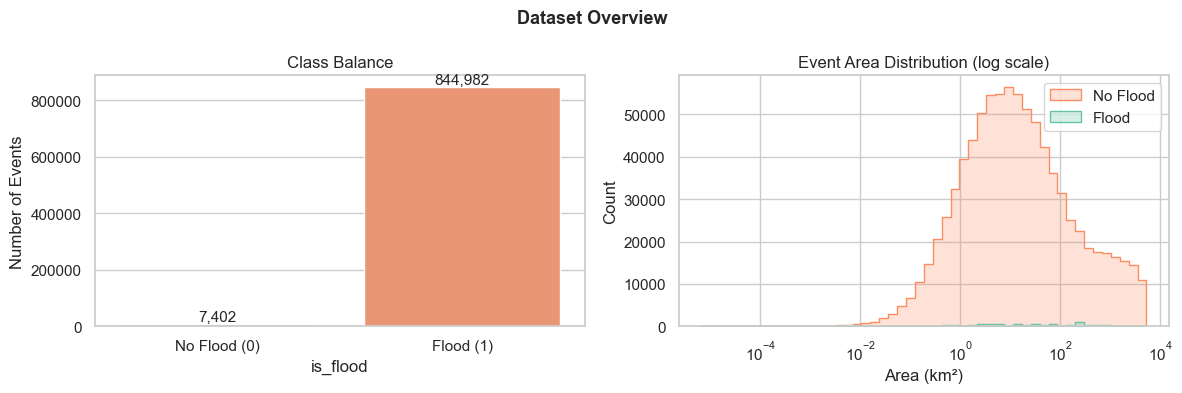

In [2]:
# ── 1. DATASET OVERVIEW ───────────────────────────────────────────
n_flood    = (df['is_flood'] == 1).sum()
n_no_flood = (df['is_flood'] == 0).sum()

print(f"Total events:    {len(df):,}")
print(f"Flood (1):       {n_flood:,}  ({n_flood/len(df)*100:.1f}%)")
print(f"No-flood (0):    {n_no_flood:,}  ({n_no_flood/len(df)*100:.1f}%)")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Dataset Overview', fontsize=13, fontweight='bold')

# Class balance
sns.countplot(data=df, x='is_flood', ax=axes[0],
              palette='Set2', order=[0, 1])
axes[0].set_title('Class Balance')
axes[0].set_xticklabels(['No Flood (0)', 'Flood (1)'])
axes[0].set_ylabel('Number of Events')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Event area distribution
if 'area_km2' in df.columns:
    sns.histplot(data=df, x='area_km2', hue='is_flood',
                 bins=50, log_scale=(True, False), ax=axes[1],
                 palette='Set2', element='step')
    axes[1].set_title('Event Area Distribution (log scale)')
    axes[1].set_xlabel('Area (km²)')
    axes[1].legend(['No Flood', 'Flood'])

plt.tight_layout()
plt.show()

Filtered dataset (urban + rainfall thresholds): 98,541 events
  Flood:    95,557
  No-flood: 2,984


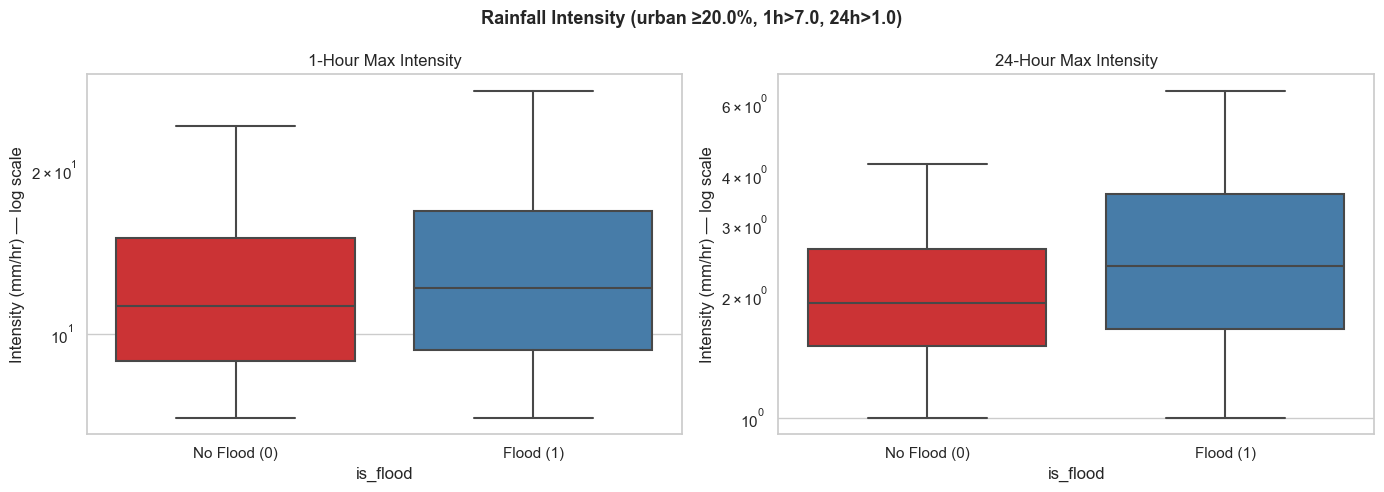

In [3]:
# ── 2. RAINFALL INTENSITY DISTRIBUTIONS ───────────────────────────
# Filtered to the same thresholds used in modelling
filtered_df = df[
    (df['urban_percentage']         >= URBAN_THRESHOLD) &
    (df['60_max_rainfall_intens']   >  THRESH_1H) &
    (df['1440_max_rainfall_intens'] >  THRESH_24H)
].copy()

print(f"Filtered dataset (urban + rainfall thresholds): {len(filtered_df):,} events")
print(f"  Flood:    {(filtered_df['is_flood']==1).sum():,}")
print(f"  No-flood: {(filtered_df['is_flood']==0).sum():,}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Rainfall Intensity (urban ≥{URBAN_THRESHOLD}%, 1h>{THRESH_1H}, 24h>{THRESH_24H})',
             fontsize=13, fontweight='bold')

for ax, col, title in [
    (axes[0], '60_max_rainfall_intens',   '1-Hour Max Intensity'),
    (axes[1], '1440_max_rainfall_intens', '24-Hour Max Intensity'),
]:
    sns.boxplot(data=filtered_df, x='is_flood', y=col,
                ax=ax, palette='Set1', showfliers=False)
    ax.set_title(title)
    ax.set_ylabel('Intensity (mm/hr) — log scale')
    ax.set_yscale('log')
    ax.set_xticklabels(['No Flood (0)', 'Flood (1)'])

plt.tight_layout()
plt.show()

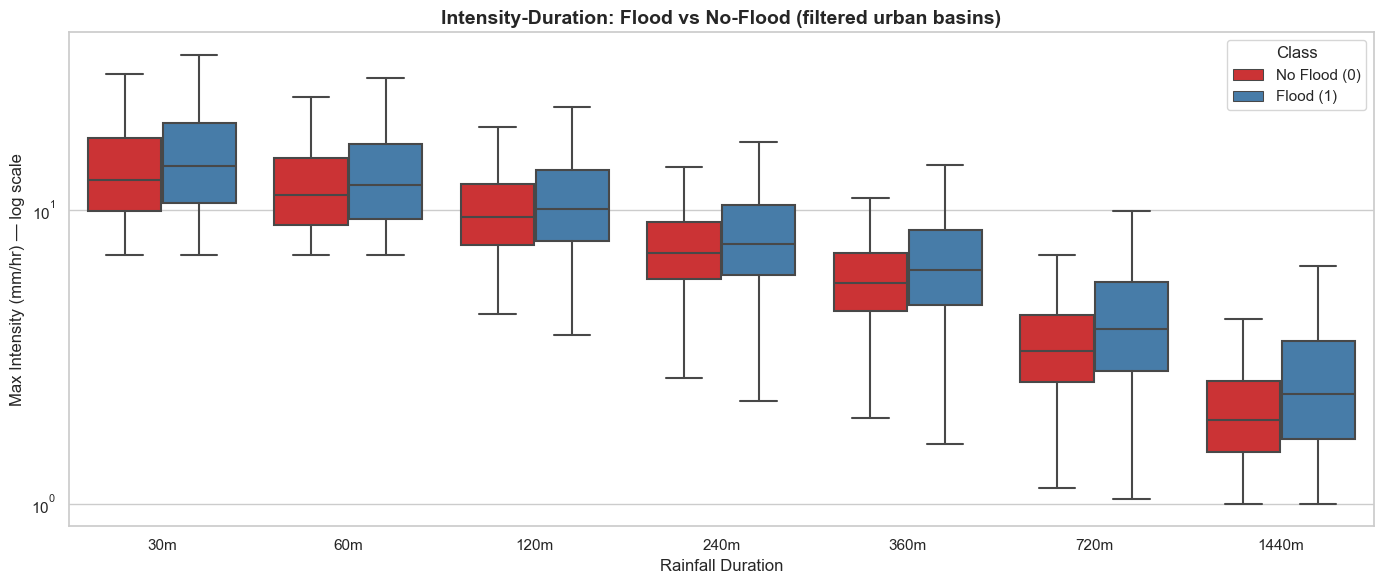

In [4]:
# ── 3. INTENSITY-DURATION CURVES (flood vs no-flood) ──────────────
avail_intensity_cols = [c for c in INTENSITY_COLS if c in filtered_df.columns]
avail_labels         = DURATION_LABELS[:len(avail_intensity_cols)]

melted_df = pd.melt(
    filtered_df,
    id_vars=['is_flood'],
    value_vars=avail_intensity_cols,
    var_name='Duration',
    value_name='Intensity (mm/hr)',
)
melted_df['Duration'] = melted_df['Duration'].apply(lambda x: x.split('_')[0] + 'm')

plt.figure(figsize=(14, 6))
ax = sns.boxplot(
    data=melted_df,
    x='Duration', y='Intensity (mm/hr)',
    hue='is_flood', palette='Set1',
    showfliers=False,
)
plt.title('Intensity-Duration: Flood vs No-Flood (filtered urban basins)',
          fontsize=14, fontweight='bold')
plt.xlabel('Rainfall Duration')
plt.ylabel('Max Intensity (mm/hr) — log scale')
plt.yscale('log')
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ['No Flood (0)', 'Flood (1)'], title='Class')
plt.tight_layout()
plt.show()

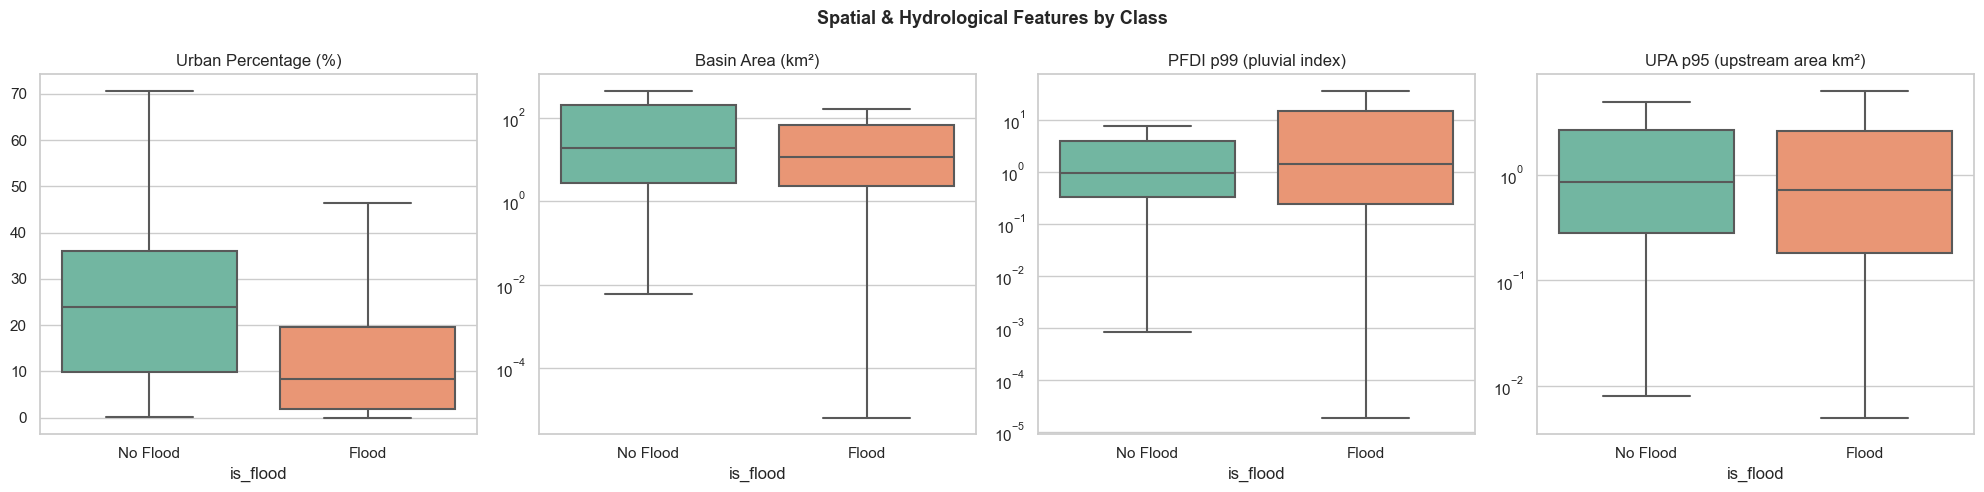


Mean values by class:
          urban_percentage  area_km2  PFDI_p99  upa_p95  60_max_rainfall_intens  1440_max_rainfall_intens
is_flood                                                                                                 
0                    24.70    120.02    207.65     8.68                   10.22                      1.80
1                    12.35    223.99    649.57   163.78                    8.75                      1.88


In [5]:
# ── 4. SPATIAL & HYDROLOGICAL FEATURES ───────────────────────────
hydro_cols = [
    ('urban_percentage',  'Urban Percentage (%)'),
    ('area_km2',          'Basin Area (km²)'),
    ('PFDI_p99',          'PFDI p99 (pluvial index)'),
    ('upa_p95',           'UPA p95 (upstream area km²)'),
]
hydro_cols = [(c, lbl) for c, lbl in hydro_cols if c in df.columns]

fig, axes = plt.subplots(1, len(hydro_cols), figsize=(5 * len(hydro_cols), 5))
fig.suptitle('Spatial & Hydrological Features by Class', fontsize=13, fontweight='bold')

for ax, (col, label) in zip(axes, hydro_cols):
    sns.boxplot(data=df, x='is_flood', y=col,
                ax=ax, palette='Set2', showfliers=False)
    ax.set_title(label)
    ax.set_ylabel('')
    ax.set_xticklabels(['No Flood', 'Flood'])
    if df[col].min() > 0:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

# Summary statistics
stat_cols = [c for c, _ in hydro_cols] + ['60_max_rainfall_intens', '1440_max_rainfall_intens']
stat_cols = [c for c in stat_cols if c in df.columns]
print("\nMean values by class:")
print(df.groupby('is_flood')[stat_cols].mean().round(2).to_string())

In [ ]:
# ── 5. FLOOD EVENTS — STANDALONE ANALYSIS ────────────────────────
flood_df = df[df['is_flood'] == 1].copy()

print(f"Flood events: {len(flood_df):,}")
print(f"\nRainfall intensity statistics (flood only):")
print(flood_df[[c for c in INTENSITY_COLS if c in flood_df.columns]].describe().round(2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Flood Events — Feature Distributions', fontsize=13, fontweight='bold')

# Duration distribution
if 'duration_days' in flood_df.columns:
    flood_df['duration_days'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='white'
    )
    axes[0].set_title('Event Duration (days)')
    axes[0].set_xlabel('Duration')
    axes[0].set_ylabel('Count')

# Area distribution
if 'area_km2' in flood_df.columns:
    axes[1].hist(flood_df['area_km2'], bins=50, color='steelblue', edgecolor='white', log=True)
    axes[1].set_xscale('log')
    axes[1].set_title('Basin Area Distribution (log-log)')
    axes[1].set_xlabel('Area (km²)')
    axes[1].set_ylabel('Count (log)')

# Urban percentage distribution
if 'urban_percentage' in flood_df.columns:
    axes[2].hist(flood_df['urban_percentage'], bins=40, color='steelblue', edgecolor='white')
    axes[2].axvline(20, color='red', linestyle='--', label='Urban threshold (20%)')
    axes[2].set_title('Urban Percentage Distribution')
    axes[2].set_xlabel('Urban %')
    axes[2].set_ylabel('Count')
    axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── 6. NO-FLOOD EVENTS — STANDALONE ANALYSIS ─────────────────────
noflood_df = df[df['is_flood'] == 0].copy()

print(f"No-flood events: {len(noflood_df):,}")
print(f"\nRainfall intensity statistics (no-flood only):")
print(noflood_df[[c for c in INTENSITY_COLS if c in noflood_df.columns]].describe().round(2))

# Extract year from start_time for temporal distribution
noflood_df['year'] = pd.to_datetime(noflood_df['start_time'], errors='coerce').dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('No-Flood Events — Feature Distributions', fontsize=13, fontweight='bold')

# Year distribution (no-flood events are sampled from 2018-2023)
if 'year' in noflood_df.columns:
    noflood_df['year'].value_counts().sort_index().plot(
        kind='bar', ax=axes[0], color='tomato', edgecolor='white'
    )
    axes[0].set_title('Events by Year')
    axes[0].set_xlabel('Year')
    axes[0].set_ylabel('Count')

# Area distribution
if 'area_km2' in noflood_df.columns:
    axes[1].hist(noflood_df['area_km2'], bins=40, color='tomato', edgecolor='white', log=True)
    axes[1].set_xscale('log')
    axes[1].set_title('Basin Area Distribution (log-log)')
    axes[1].set_xlabel('Area (km²)')
    axes[1].set_ylabel('Count (log)')

# Intensity-duration comparison with flood events (median line)
avail = [c for c in INTENSITY_COLS if c in df.columns]
medians_flood   = flood_df[avail].median()
medians_noflood = noflood_df[avail].median()
labels = DURATION_LABELS[:len(avail)]

axes[2].plot(labels, medians_flood.values,   'o-', color='steelblue', label='Flood median')
axes[2].plot(labels, medians_noflood.values, 's--', color='tomato',   label='No-Flood median')
axes[2].set_title('Median Intensity-Duration Comparison')
axes[2].set_xlabel('Duration')
axes[2].set_ylabel('Median Intensity (mm/hr)')
axes[2].legend()
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# ── 7. WORLD MAP — SPATIAL DISTRIBUTION OF EVENTS ────────────────
# Requires centroid_lon / centroid_lat columns produced by 05a.
# Uses plotly for an interactive map; falls back to matplotlib if unavailable.

map_df = df[['centroid_lon', 'centroid_lat', 'is_flood', 'area_km2']].dropna()

try:
    import plotly.express as px

    map_df['Class'] = map_df['is_flood'].map({1: 'Flood', 0: 'No-Flood'})

    fig = px.scatter_geo(
        map_df,
        lat='centroid_lat',
        lon='centroid_lon',
        color='Class',
        color_discrete_map={'Flood': 'steelblue', 'No-Flood': 'tomato'},
        size='area_km2',
        size_max=8,
        opacity=0.5,
        projection='natural earth',
        title='Global Distribution of Flood and No-Flood Events',
        hover_data={'centroid_lat': ':.2f', 'centroid_lon': ':.2f', 'area_km2': ':.1f'},
    )
    fig.update_layout(height=550, margin=dict(l=0, r=0, t=40, b=0))
    fig.show()

except ImportError:
    # Fallback: static matplotlib map using geopandas world boundaries
    import geopandas as gpd

    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

    fig, ax = plt.subplots(figsize=(18, 9))
    world.plot(ax=ax, color='lightgrey', edgecolor='white', linewidth=0.3)

    for label, color, marker in [
        ('Flood',    'steelblue', 'o'),
        ('No-Flood', 'tomato',    's'),
    ]:
        subset = map_df[map_df['is_flood'] == (1 if label == 'Flood' else 0)]
        ax.scatter(
            subset['centroid_lon'], subset['centroid_lat'],
            s=4, alpha=0.4, color=color, marker=marker, label=label
        )

    ax.set_title('Global Distribution of Flood and No-Flood Events', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend(markerscale=3)
    ax.set_xlim(-180, 180)
    ax.set_ylim(-90, 90)
    plt.tight_layout()
    plt.show()

print(f"\nMapped events: {len(map_df):,} (excluded {len(df) - len(map_df):,} with missing coordinates)")